# 수업 에일리업 vs 프레데터 복사 타이핑하기

In [1]:
from pathlib import Path

PROJECT_DIR = Path.cwd()
PROJECT_DIR

WindowsPath('C:/LANG_CHAIN_2026/2026-05-19_KDT_lang_chain/workspace/python/14_scikit_learn')

In [2]:
DATA_DIR = PROJECT_DIR / "data" / "alien_vs_predator_images" / "data"

print(f"프로젝트 폴더: {PROJECT_DIR}")
print(f"데이터 폴더: {DATA_DIR}")

프로젝트 폴더: C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\workspace\python\14_scikit_learn
데이터 폴더: C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\workspace\python\14_scikit_learn\data\alien_vs_predator_images\data


In [3]:
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "validation"

print(f"학습 데이터 폴더: {TRAIN_DIR}")
print(f"검증 데이터 폴더: {VAL_DIR}")

학습 데이터 폴더: C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\workspace\python\14_scikit_learn\data\alien_vs_predator_images\data\train
검증 데이터 폴더: C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\workspace\python\14_scikit_learn\data\alien_vs_predator_images\data\validation


In [4]:
IMAGE_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.224]

In [5]:
from torchvision import transforms, datasets, models

In [7]:
data_transforms = {
    "train": transforms.Compose([
        transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomAffine(degrees=8, shear=8),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ]),
    "validation": transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ])
}

In [9]:
image_datasets = {
    "train": datasets.ImageFolder(
        TRAIN_DIR,
        transform=data_transforms["train"],
    ),
    "validation": datasets.ImageFolder(
        VAL_DIR,
        transform=data_transforms["validation"]
    )
}

In [11]:
class_names = image_datasets["train"].classes
print(class_names)
class_to_idx = image_datasets["train"].class_to_idx
print(class_to_idx)
idx_to_class = {
    idx: name
    for name, idx
    in class_to_idx.items()
}
idx_to_class

['alien', 'predator']
{'alien': 0, 'predator': 1}


{0: 'alien', 1: 'predator'}

In [12]:
import torch
from torch import nn
from torch import optim
from torch.utils.data import DataLoader

In [13]:
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(DEVICE)

cuda


In [14]:
BATCH_SIZE = 32
NUM_WORKERS = 0
PIN_MEMORY = (DEVICE.type == "cuda")
SEED = 42

In [15]:
generator = torch.Generator()
generator.manual_seed(SEED)

In [19]:
dataloaders = {
    "train": DataLoader(
        image_datasets["train"],
        batch_size=BATCH_SIZE,
        shuffle=True,
        pin_memory=PIN_MEMORY,
        generator=generator,
        persistent_workers=(NUM_WORKERS > 0)
    ),
    "validation": DataLoader(
        dataset=image_datasets["validation"],
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS>0)
    )
}

In [20]:
images, labels = next(iter(dataloaders["train"]))

print("images batch shape:", images.shape)
print("labels batch shape:", labels.shape)
print("labels dtype:", labels.dtype)

images batch shape: torch.Size([32, 3, 224, 224])
labels batch shape: torch.Size([32])
labels dtype: torch.int64


In [21]:
import matplotlib.pyplot as plt

In [25]:
def denormalize_image(image_tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    image = image_tensor.cpu() * std + mean

    return image.clamp(0, 1)

In [28]:
next(iter(dataloaders["train"]))[0].shape

torch.Size([32, 3, 224, 224])

In [30]:
next(iter(dataloaders["train"]))[1].unsqueeze(1).shape

torch.Size([32, 1])

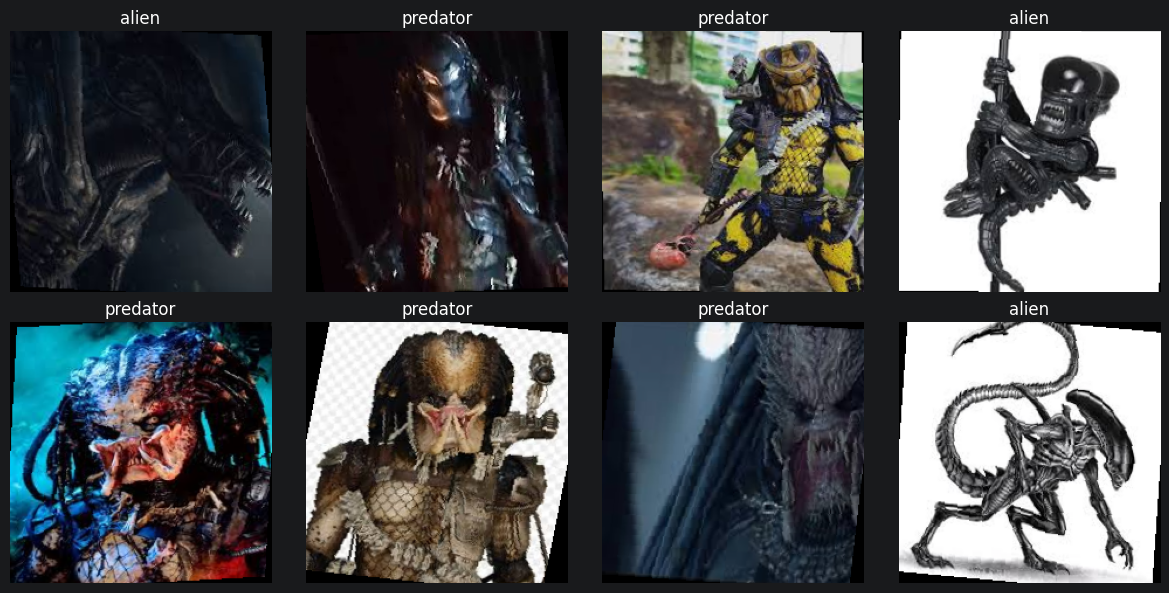

In [26]:
images, labels = next(iter(dataloaders["train"]))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax, image, label in zip(axes.flatten(), images[:8], labels[:8]):
    ax.imshow(denormalize_image(image).permute(1, 2, 0))
    ax.set_title(idx_to_class[label.item()])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [31]:
from torchvision.models import AlexNet_Weights

In [43]:
weights = AlexNet_Weights.IMAGENET1K_V1
model = models.alexnet(weights=weights)
model

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [48]:
for parameter in model.parameters():
    parameter.requires_grad=False

In [49]:
in_features = model.classifier[6].in_features
model.classifier[6] = nn.Linear(in_features, 1)
model.to(DEVICE)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [50]:
model.classifier

Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=9216, out_features=4096, bias=True)
  (2): ReLU(inplace=True)
  (3): Dropout(p=0.5, inplace=False)
  (4): Linear(in_features=4096, out_features=4096, bias=True)
  (5): ReLU(inplace=True)
  (6): Linear(in_features=4096, out_features=1, bias=True)
)

In [51]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total_params, trainable_params

(57007937, 4097)

In [ ]:
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.AdamW(
    filter(lambda p: p.required_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)